In [33]:
# Import necessary libraries
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
from scipy.stats import linregress
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Ensure output folder exists for all exported figures
FIG_DIR = Path("Figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Question 2: Data Download 

Login here with your credentials for Copernicus Marine website.

Link to the dataset:
[BALTICSEA_MULTIYEAR_BGC_003_012](https://data.marine.copernicus.eu/product/BALTICSEA_MULTIYEAR_BGC_003_012/description?pk_vid=20588a7d3983f1131776235323b81fe6)

Dataset ID: cmems mod bal bgc my P1Dm

### Available Variables:
- Chlorophyll-a (chl)
- Nitrate (no3)
- Phosphate (po4)
- Ammonium (nh4)
- Dissolved Oxygen (o2)
- Bottom Dissolved Oxygen (o2b)
- Ph (ph)
- Partial CO2 pressure at the surface (spco2)
- Secchi Depth (zsd)
- Net primary production (nppv)

In [ ]:
# Download the data for the year 2018 for the variable o2b in the Aarhus Bay region
copernicusmarine.subset(
    dataset_id="cmems_mod_bal_bgc_my_P1D-m",
    variables=["o2b"],
    minimum_longitude=0.82,
    maximum_longitude=20.71,
    minimum_latitude=45.75,
    maximum_latitude=66.31,
    start_datetime="2018-01-01T00:00:00",
    end_datetime="2018-12-31T23:59:59",
    output_directory="Data",
    output_filename="cmems_o2b_2018.nc",
    force_download=True
)

In [ ]:
# Download the data for the year 2018 for the variable deptho in the Aarhus Bay region
 copernicusmarine.subset(
    dataset_id="cmems_mod_bal_bgc_my_static",
    variables=["deptho"],
    minimum_longitude=9.82,
    maximum_longitude=10.71,
    minimum_latitude=55.75,
    maximum_latitude=56.31,
    output_directory="Data",
    output_filename="cmems_deptho_2018.nc",
)

In [35]:
# Load the dataset
ds_o2b = xr.open_dataset("Data/cmems_o2b_2018.nc")
ds_depth = xr.open_dataset("Data/cmems_deptho_2018.nc")

# Question 3: Plot oxygen near seabed

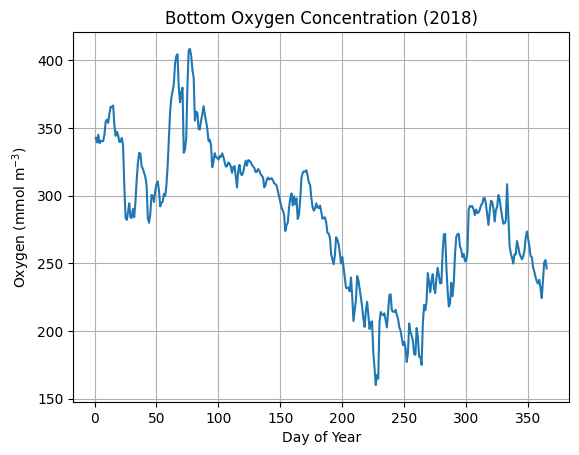

In [41]:
# Position given in the exercise
lon_target = 10.34705
lat_target = 56.09158

point = ds_o2b.sel(longitude=lon_target, latitude=lat_target, method="nearest")

# Day of the yeat as the x axis that can range from 1 to 366
day_of_year = point.time.dt.dayofyear

# Extract the oxygen values
o2 = point["o2b"]

#Plot the oxygen concentration near the seabed
plt.figure()
plt.plot(day_of_year, o2)
plt.xlabel("Day of Year")
plt.ylabel("Oxygen (mmol m$^{-3}$)")
plt.title("Bottom Oxygen Concentration (2018)")
plt.grid()


# Code for automatic plot saving (Modify as needed for each plot)
plt.savefig(FIG_DIR / "Plot_o2.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Question 4 : Map with time-average and lowest oxygen concentration near the seabed for the year 2018


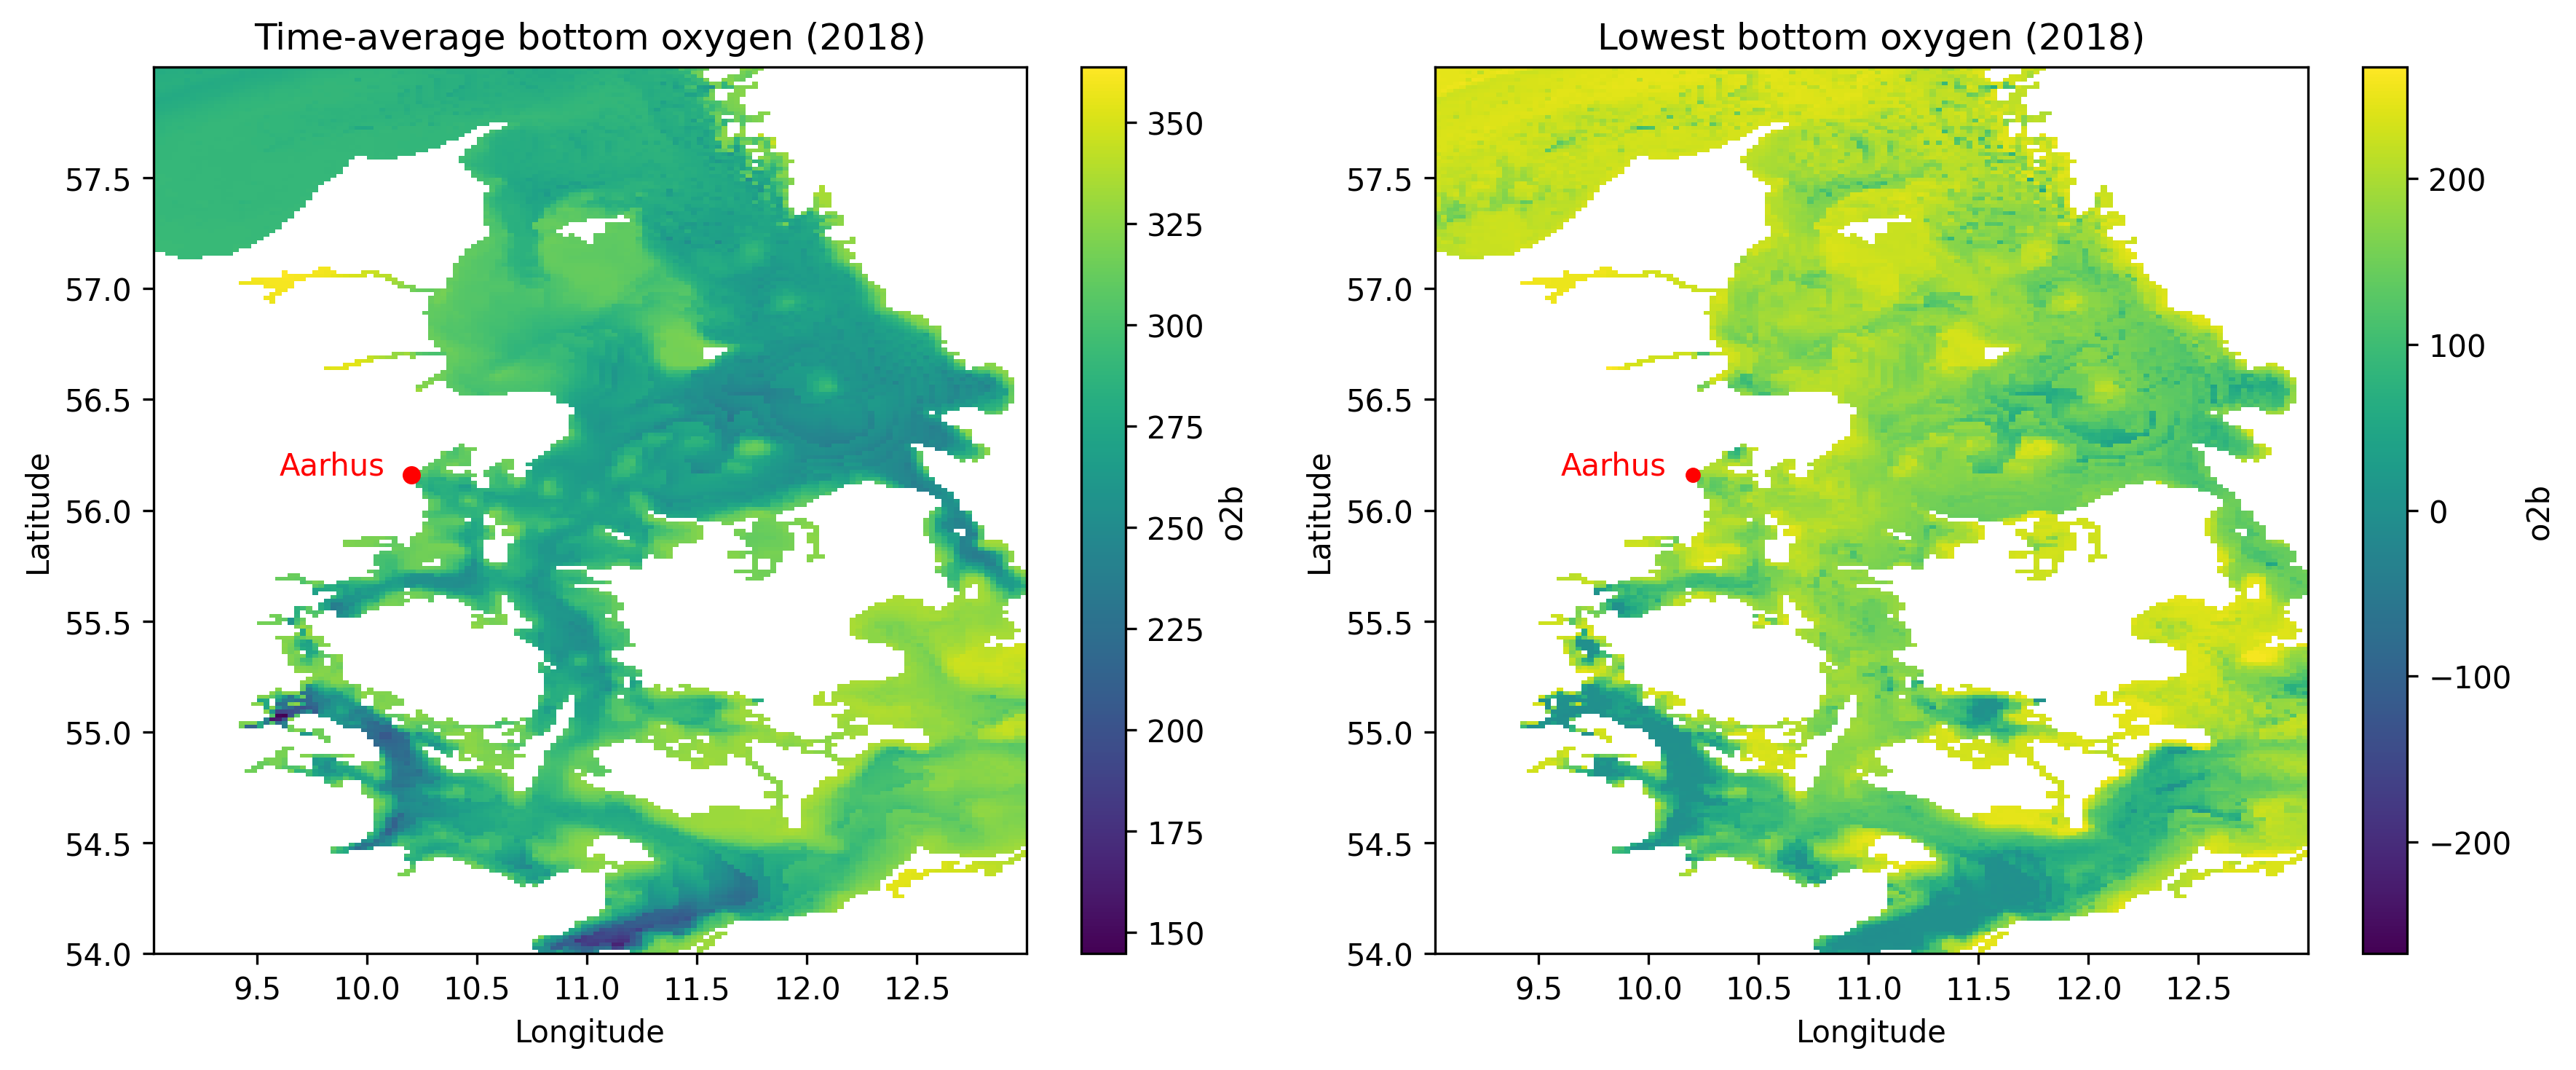

In [45]:
# Restrict to requested plotting region
ds_region = ds_o2b.sel(longitude=slice(9, 13), latitude=slice(54, 58))

# Compute statistics over time inside the region
o2b_mean = ds_region["o2b"].mean(dim="time")
o2b_min = ds_region["o2b"].min(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Map: time-average and lowest bottom oxygen
# Colorful map in viridus color scheme

o2b_mean.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Time-average bottom oxygen (2018)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

o2b_min.plot(ax=axes[1], cmap="viridis")
axes[1].set_title("Lowest bottom oxygen (2018)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# Aarhus Bay station position
lat_target = 56.16
lon_target = 10.2

# Add the dot for the position of the station
axes[0].plot(lon_target, lat_target, marker="o", color="red", markersize=5, label="Station")
axes[0].annotate("Aarhus", xy=(lon_target, lat_target), xytext=(lon_target - 0.12, lat_target), color="red", ha="right")
axes[1].plot(lon_target, lat_target, marker="o", color="red", markersize=4, label="Station")
axes[1].annotate("Aarhus", xy=(lon_target, lat_target), xytext=(lon_target - 0.12, lat_target), color="red", ha="right")


plt.tight_layout()
plt.savefig(FIG_DIR / "o2b_mean_min_maps_2018.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

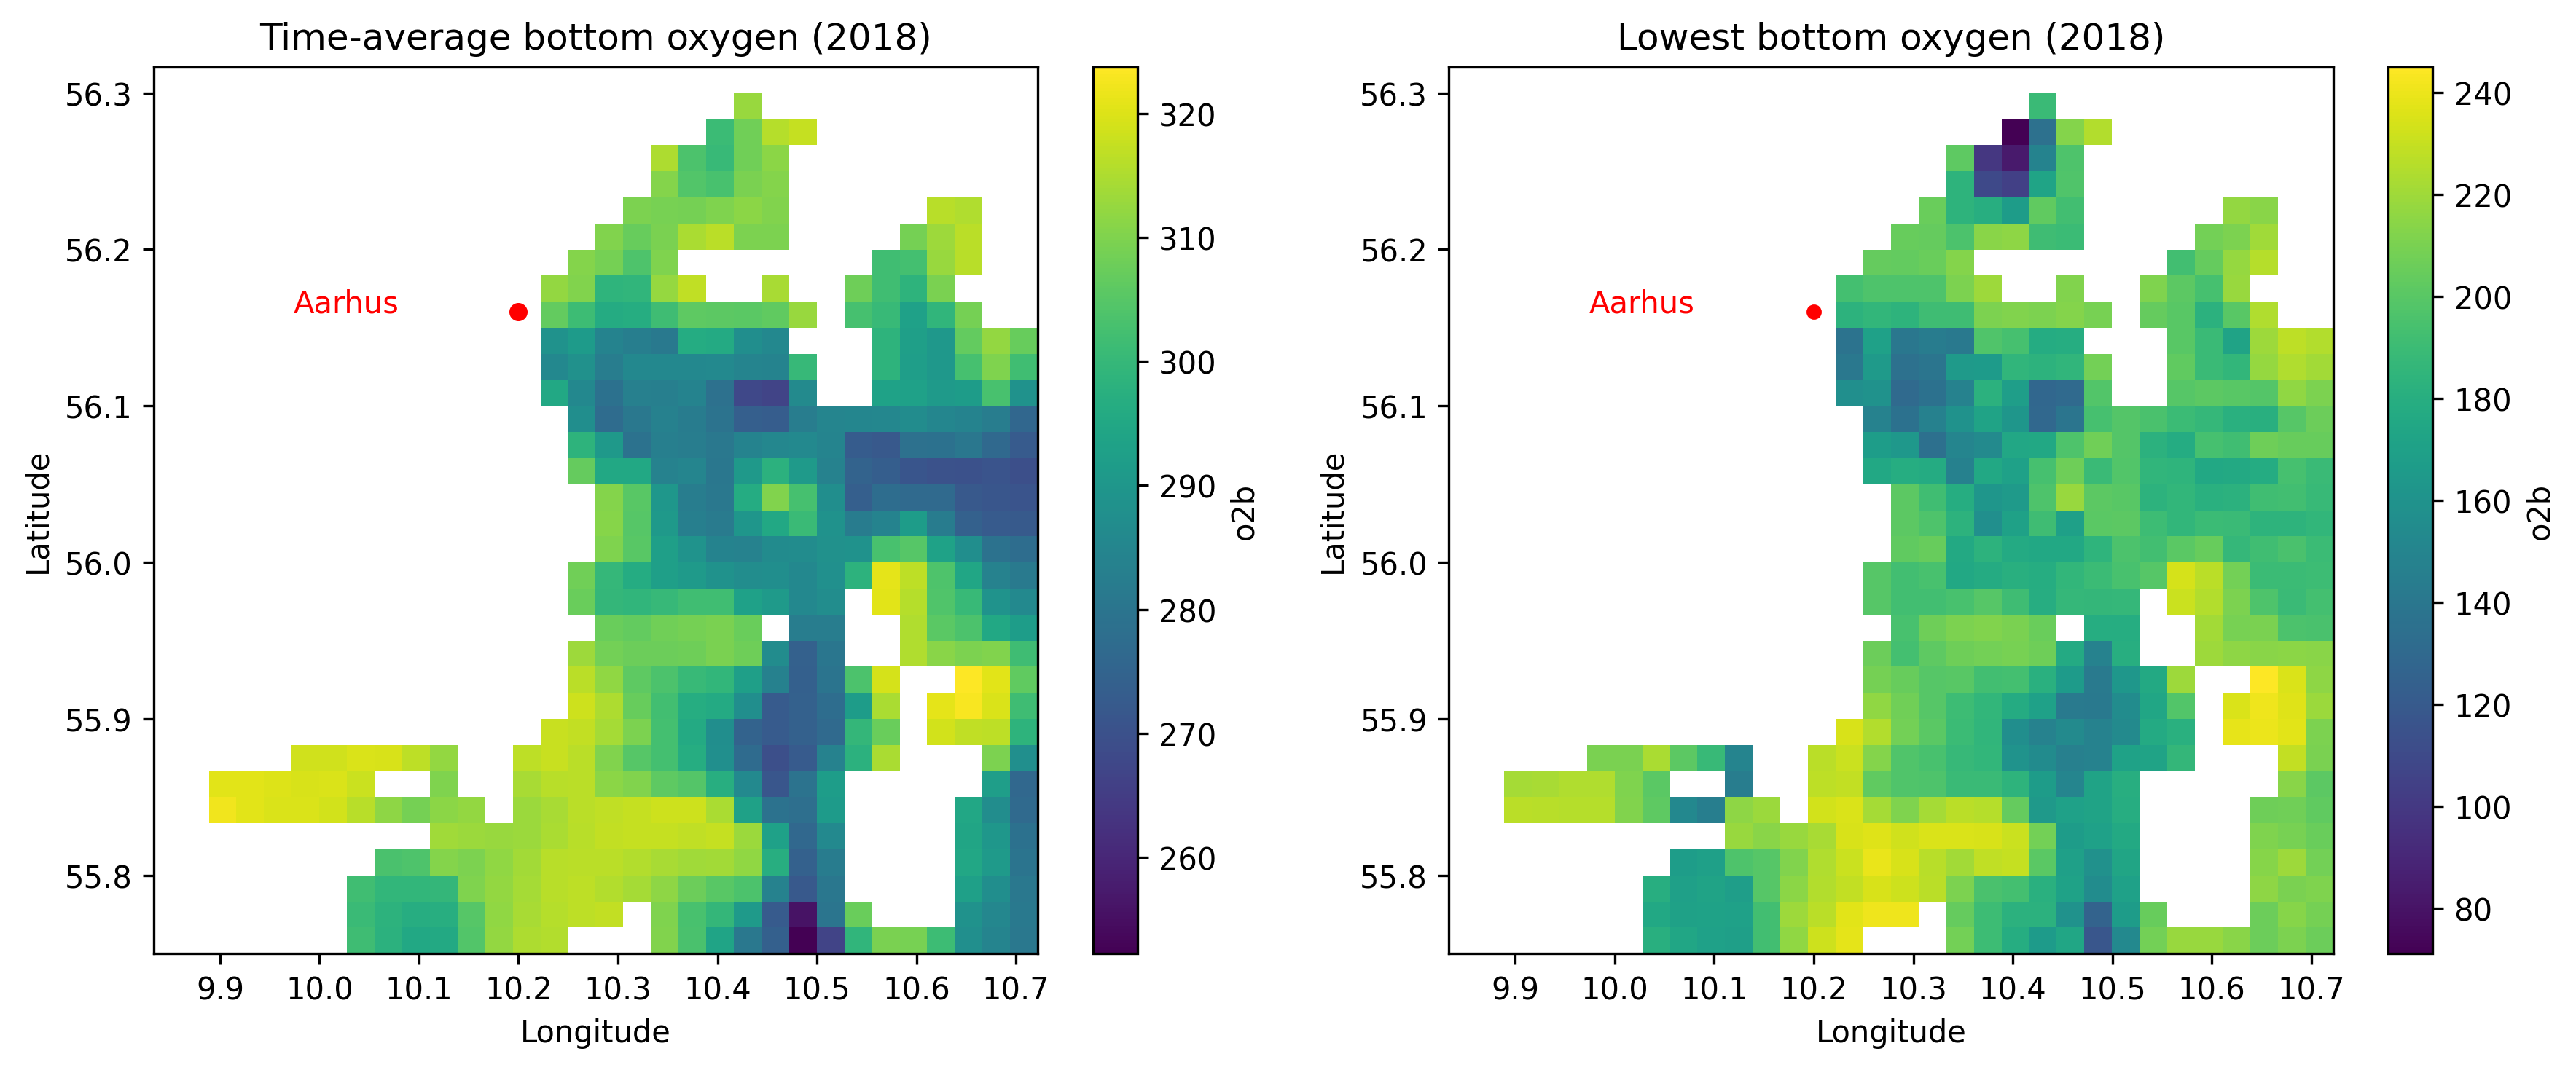

In [46]:
# Restrict to requested plotting region
ds_region = ds_o2b.sel(longitude=slice(9.82, 10.71), latitude=slice(55.75, 56.31))

# Compute statistics over time inside the region
o2b_mean = ds_region["o2b"].mean(dim="time")
o2b_min = ds_region["o2b"].min(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Map: time-average and lowest bottom oxygen
# Colorful map in viridus color scheme

o2b_mean.plot(ax=axes[0], cmap="viridis")
axes[0].set_title("Time-average bottom oxygen (2018)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

o2b_min.plot(ax=axes[1], cmap="viridis")
axes[1].set_title("Lowest bottom oxygen (2018)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# Aarhus Bay station position
lat_target = 56.16
lon_target = 10.2

# Add the dot for the position of the station
axes[0].plot(lon_target, lat_target, marker="o", color="red", markersize=5, label="Station")
axes[0].annotate("Aarhus", xy=(lon_target, lat_target), xytext=(lon_target - 0.12, lat_target), color="red", ha="right")
axes[1].plot(lon_target, lat_target, marker="o", color="red", markersize=4, label="Station")
axes[1].annotate("Aarhus", xy=(lon_target, lat_target), xytext=(lon_target - 0.12, lat_target), color="red", ha="right")


plt.tight_layout()
plt.savefig(FIG_DIR / "o2b_mean_min_maps_2018_closegrid.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Question 5 : Map that shows points where oxygen was above 5 ml/L during year 2018

Threshold in mmol m^-3: 223.30400607386895


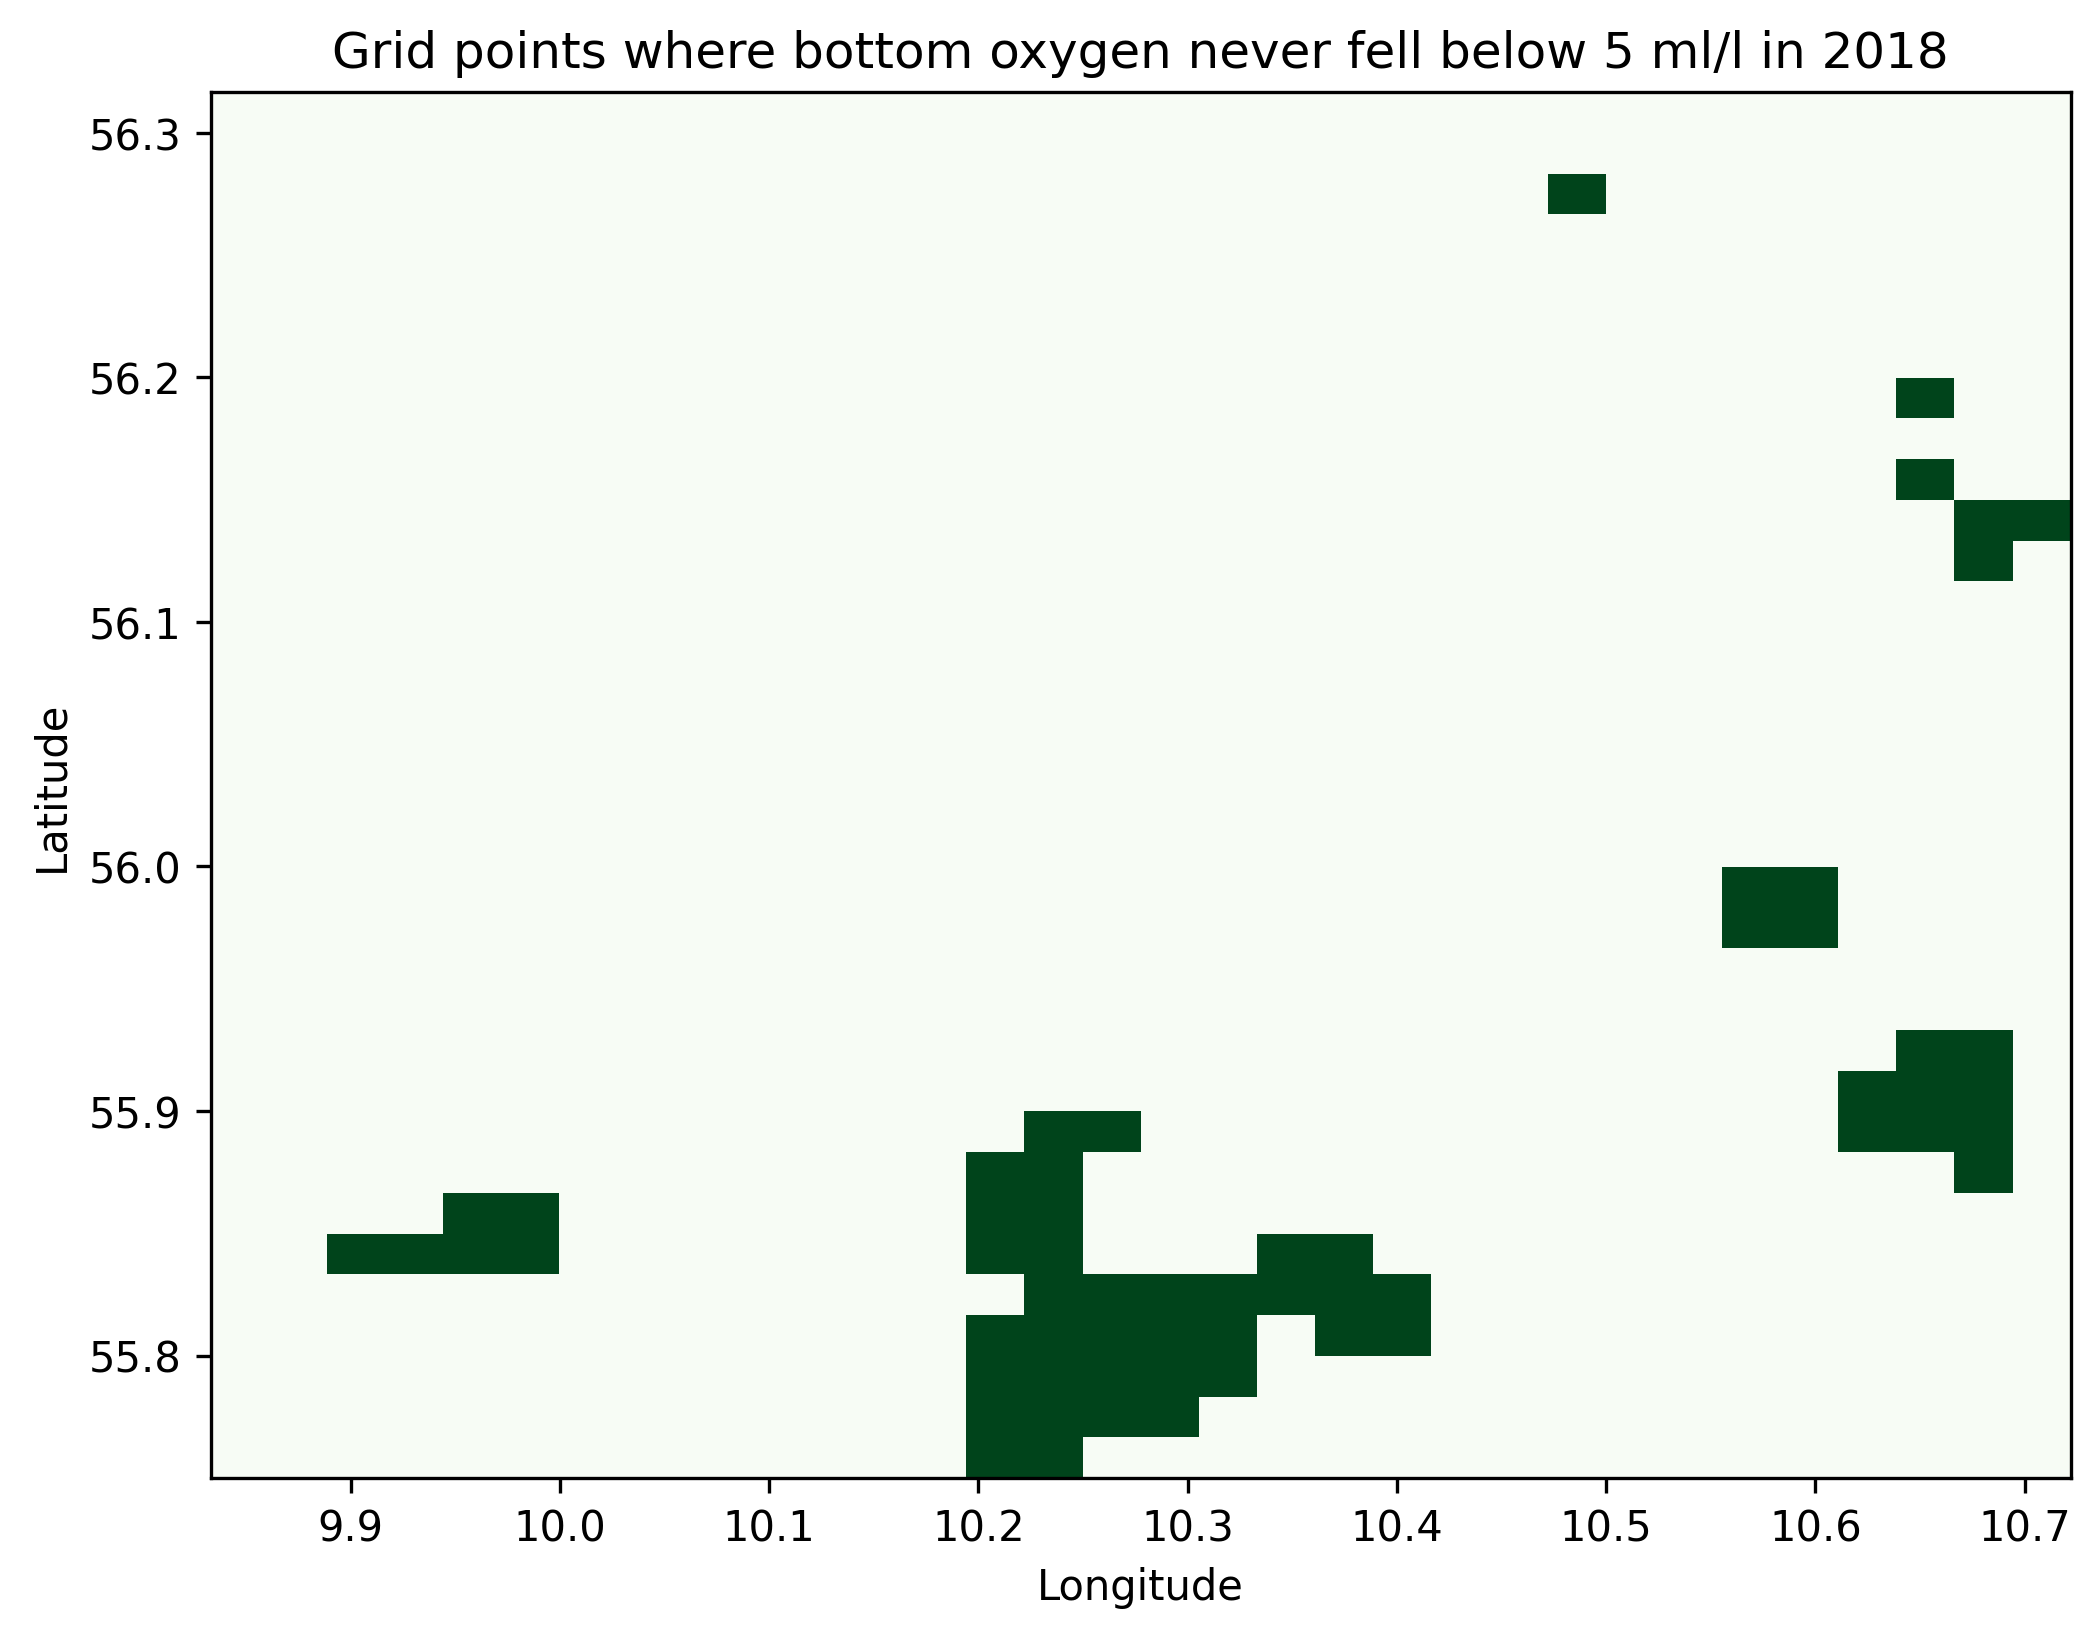

In [37]:
# Restrict to requested plotting region
ds_region = ds_o2b.sel(longitude=slice(9.82, 10.71), latitude=slice(55.75, 56.31))

# Convert threshold: converting into the units used in copernicus dataset (mmol/m^3)
# 5 ml/l -> mmol/m^3
threshold_ml_l = 5
threshold_mmol_m3 = threshold_ml_l / 0.022391

print("Threshold in mmol m^-3:", threshold_mmol_m3)

# Minimum oxygen during the year at each grid point (inside region)
o2b_min = ds_region["o2b"].min(dim="time")

# Mask: True where oxygen has NEVER been below 5 ml/l (>= 5ml/L)
safe_points = o2b_min >= threshold_mmol_m3

# Plot
plt.figure(figsize=(8, 6), dpi=300)
safe_points.plot(cmap="Greens", add_colorbar=False)

plt.title("Grid points where bottom oxygen never fell below 5 ml/l in 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig(FIG_DIR / "o2b_never_below_5mlL_2018.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Question 6 : Linear regression of water depth and lowest oxygen concentrations

In [38]:
# Getting the data for the depth
# Minimum oxygen per grid cell (over time)
o2b_min = ds_region["o2b"].min(dim="time")

# Depth variable
depth = ds_depth["deptho"]

# Flatten and remove missing or invalid data points
x = depth.values.flatten()
y = o2b_min.values.flatten()

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

In [39]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

r2 = r_value**2
print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r2)

Slope: -2.6388243370082387
Intercept: 223.72344301115209
R²: 0.25481283072418487


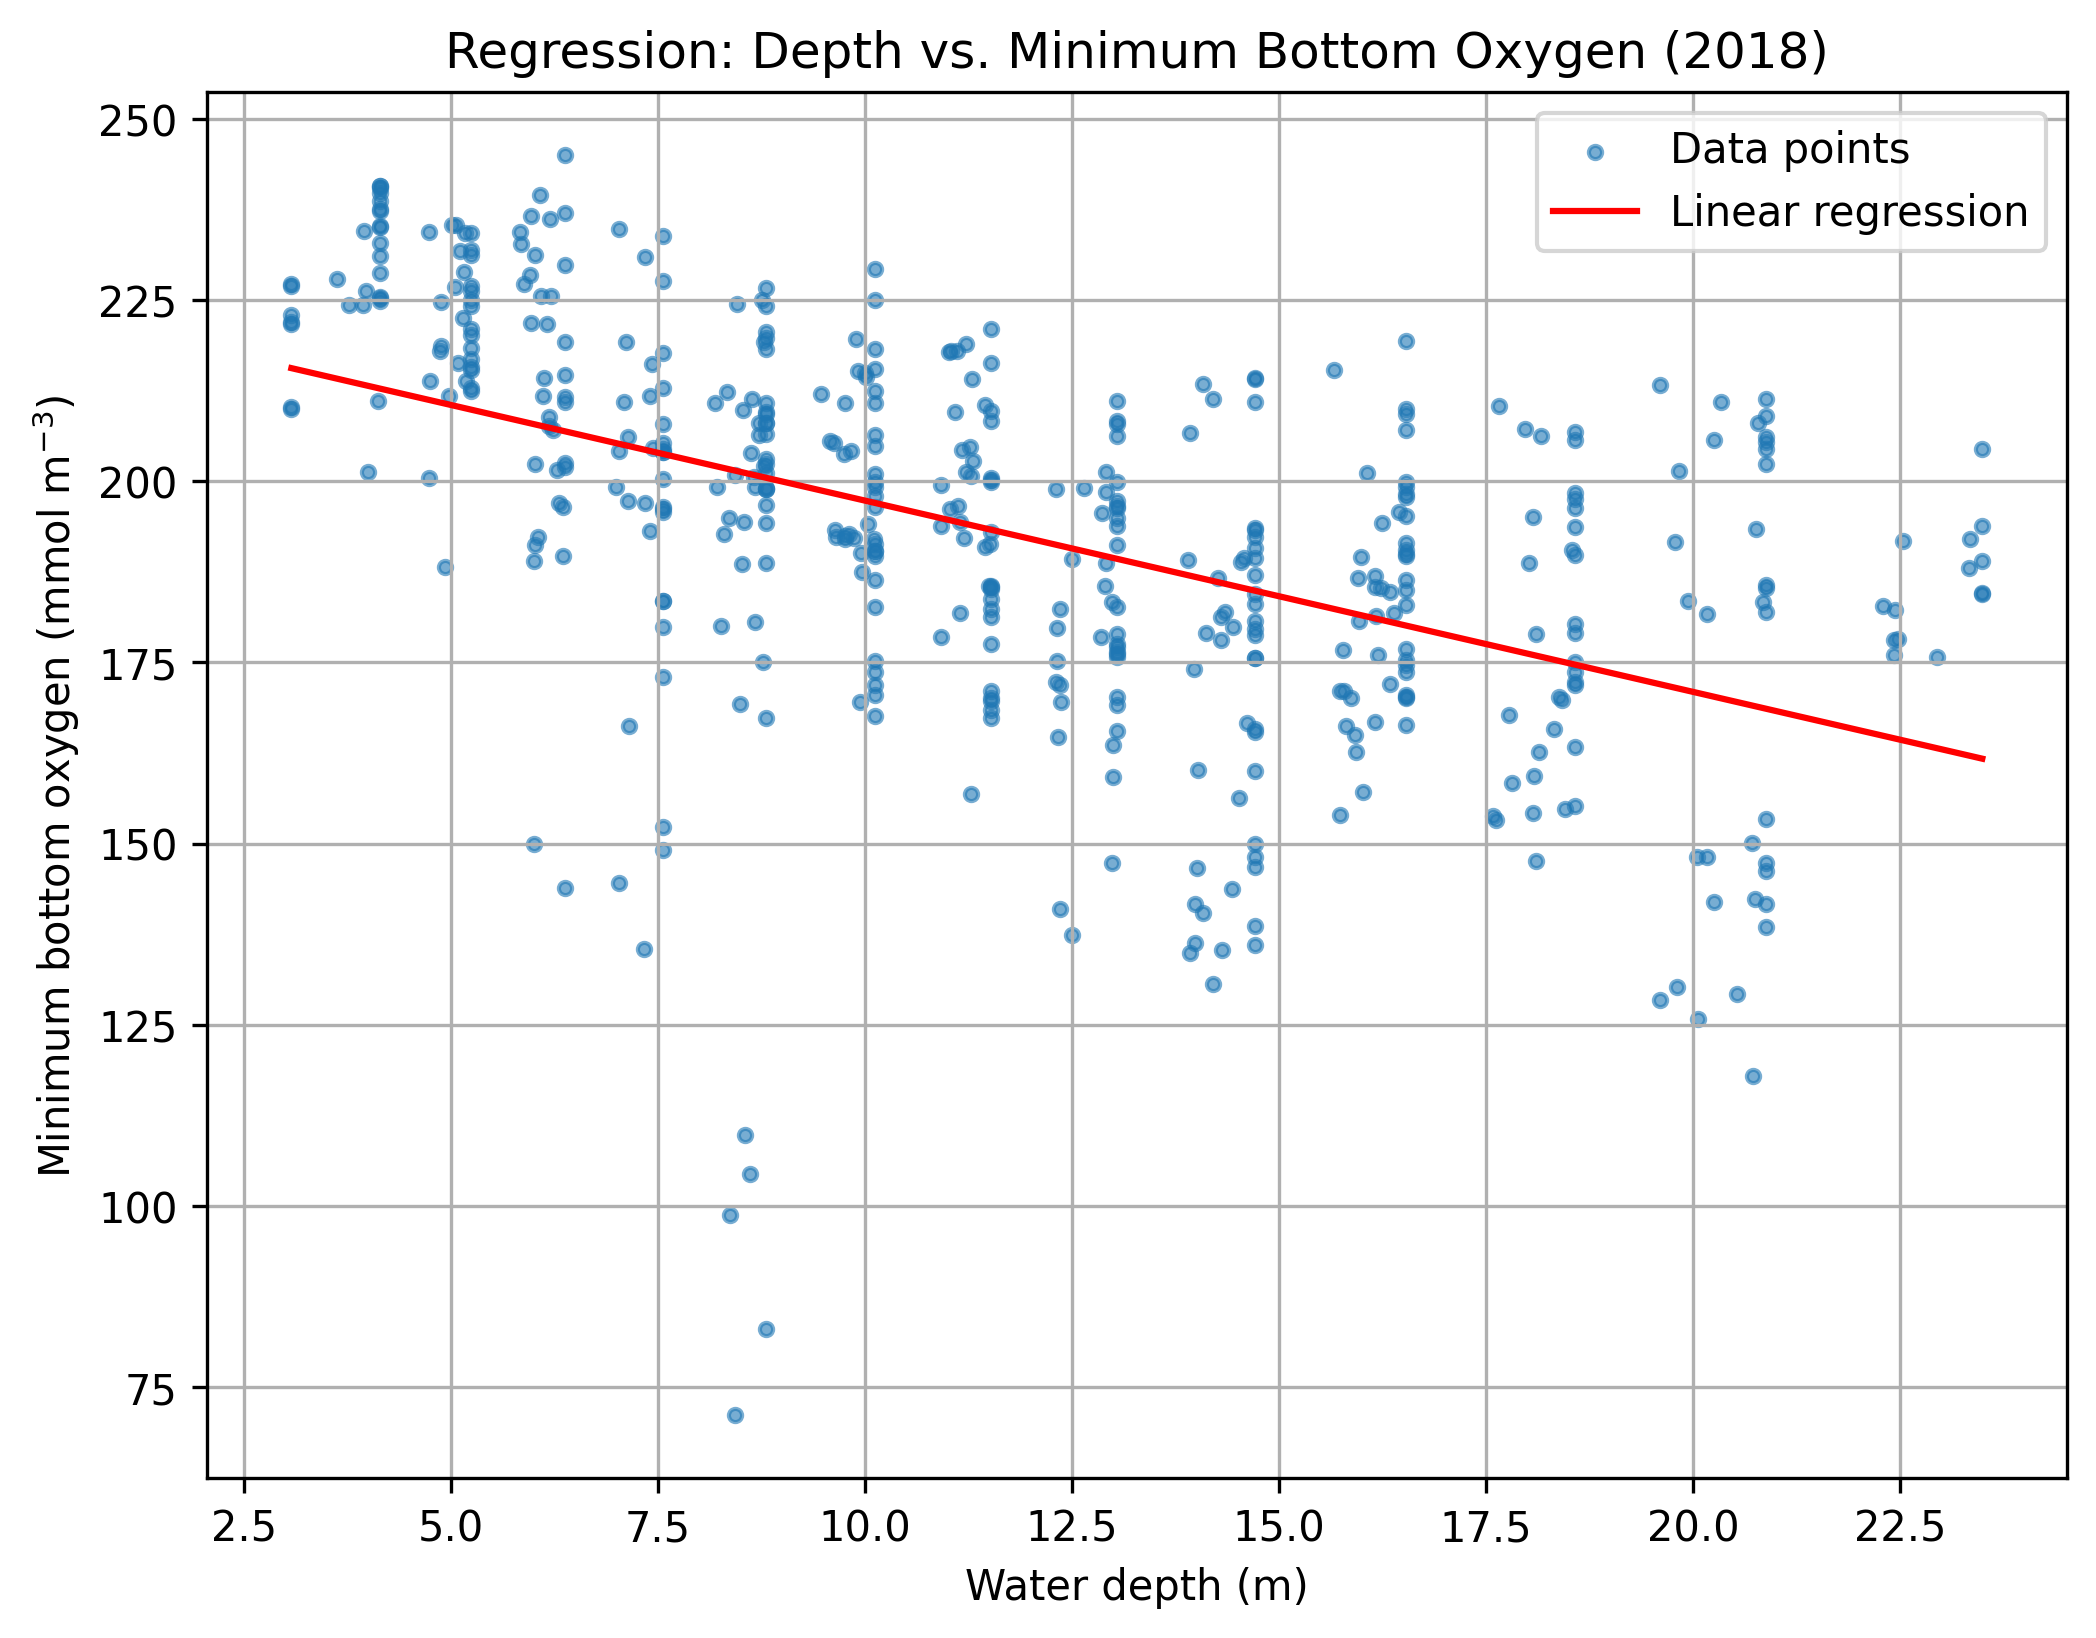

In [40]:
# Plot the Linear regression
plt.figure(figsize=(8, 6), dpi=300)

# Scatter points
plt.scatter(x, y, s=10, alpha=0.6, label="Data points")

# Regression line
x_line = np.linspace(min(x), max(x), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="red", label="Linear regression")

plt.xlabel("Water depth (m)")
plt.ylabel("Minimum bottom oxygen (mmol m$^{-3}$)")
plt.title("Regression: Depth vs. Minimum Bottom Oxygen (2018)")

plt.legend()
plt.grid()

plt.savefig(FIG_DIR / "depth_vs_o2_regression.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()